<a href="https://colab.research.google.com/github/anthony-yt/wildfire-cellular-automata/blob/main/notebooks/viz_prueba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Validación del módulo de visualización

Este notebook verifica que `src/viz/plot_grid.py` renderice correctamente los cuatro estados del autómata celular y que las funciones `dibujar_grid` y `animar_grid` produzcan salidas visualmente coherentes con la dinámica del modelo.

Se prueba sobre el modelo de propagación del Frente 2 (`src.model.grid.Grid`), sin viento ni pendiente, para evaluar exclusivamente la capa de representación gráfica.

## Convención de estados

| Código | Estado | Color | Descripción |
|:---:|:---|:---|:---|
| 0 | Sana | Verde (`#2ecc71`) | Vegetación viva, combustible disponible |
| 1 | Quemándose | Rojo (`#e74c3c`) | Frente de fuego activo |
| 2 | Quemada | Negro (`#111111`) | Biomasa consumida, material inerte |
| 3 | No-combustible | Gris (`#95a5a6`) | Barreras naturales (rocas, agua, caminos) |

La paleta utiliza `ListedColormap` con `BoundaryNorm` (límites semienteros) para garantizar una correspondencia discreta exacta entre valores enteros y colores, sin interpolación.

In [1]:
import os

if os.path.exists('src'):
    pass
elif os.path.exists('../src'):
    %cd ..
else:
    if not os.path.exists('wildfire-cellular-automata'):
        !git clone https://github.com/anthony-yt/wildfire-cellular-automata.git
    %cd wildfire-cellular-automata

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML

from src.viz.plot_grid import dibujar_grid, animar_grid, generar_grid_dummy
from src.model.grid import Grid, SANA, NO_COMBUSTIBLE

## Visualización estática

Se inicializa una grilla de $50 \times 50$ con un foco de ignición central y **80 celdas no-combustibles** distribuidas aleatoriamente, de modo que la prueba cubra los 4 estados del modelo.

Se ejecutan 5 pasos de propagación estocástica, delegando la renderización a `dibujar_grid`.

In [3]:
grid = Grid(tamano=50, prob_ignicion_base=0.3, pasos_para_quemarse=2, semilla=42)

# Insertar celdas no-combustibles para validar la renderización de los 4 estados
rng = np.random.default_rng(99)
for _ in range(80):
    r, c = rng.integers(0, grid.tamano, size=2)
    if grid.estado[r, c] == SANA:
        grid.estado[r, c] = NO_COMBUSTIBLE

centro = grid.tamano // 2
grid.encender_celda(centro, centro)

grid.contar_estados()

{'Sana': 2423, 'Quemandose': 1, 'Quemada': 0, 'No_combustible': 76}

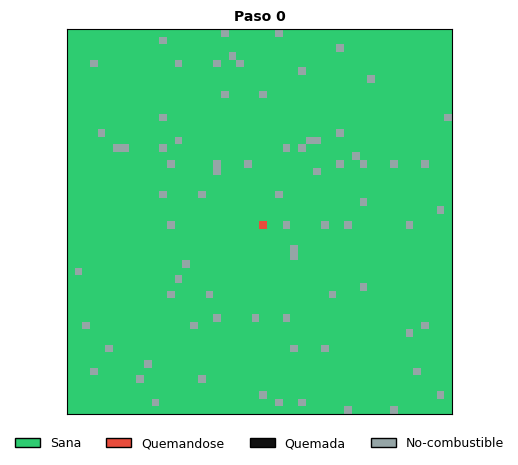

Paso 1: {'Sana': 2421, 'Quemandose': 3, 'Quemada': 0, 'No_combustible': 76}


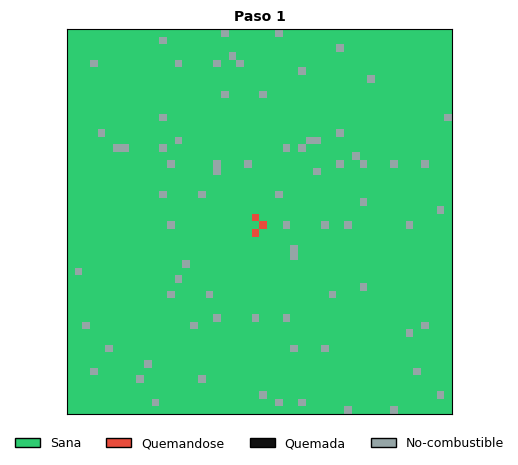

Paso 2: {'Sana': 2418, 'Quemandose': 5, 'Quemada': 1, 'No_combustible': 76}


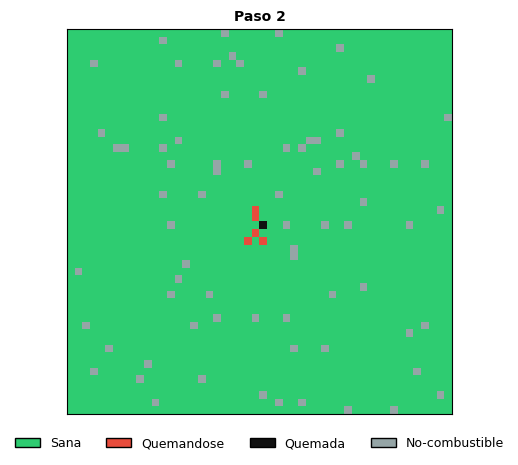

Paso 3: {'Sana': 2414, 'Quemandose': 7, 'Quemada': 3, 'No_combustible': 76}


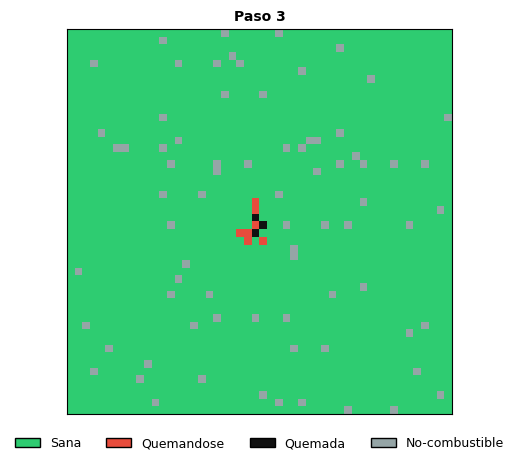

Paso 4: {'Sana': 2412, 'Quemandose': 6, 'Quemada': 6, 'No_combustible': 76}


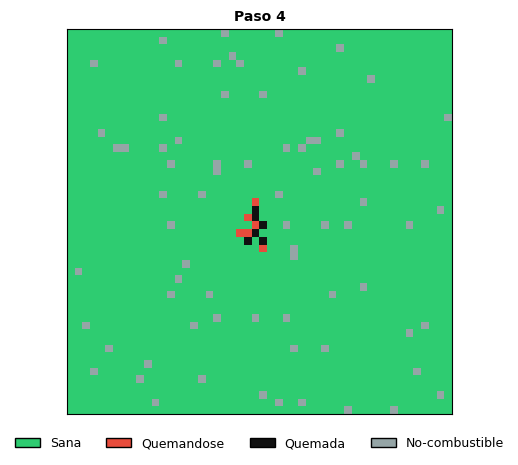

Paso 5: {'Sana': 2410, 'Quemandose': 4, 'Quemada': 10, 'No_combustible': 76}


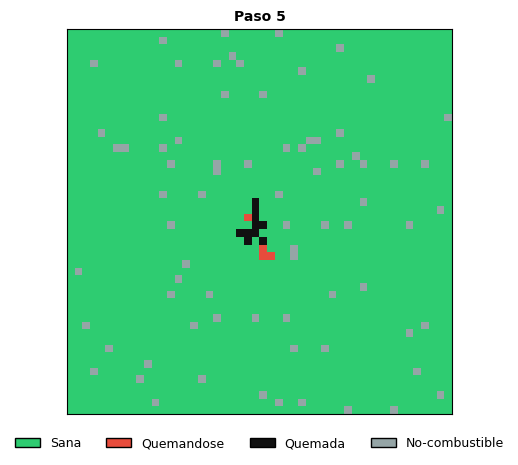

In [4]:
fig, ax, im = dibujar_grid(grid.estado, titulo="Paso 0")
plt.show()

for paso in range(1, 6):
    grid.paso_tiempo()
    print(f"Paso {paso}:", grid.contar_estados())
    fig, ax, im = dibujar_grid(grid.estado, titulo=f"Paso {paso}")
    plt.show()

## Evolución temporal

Para validar que la renderización distingue correctamente los 4 estados a lo largo del tiempo, se utiliza el generador sintético `generar_grid_dummy` con 2 focos de ignición y un 10% de celdas no combustibles. El mosaico permite verificar visualmente que las barreras permanecen inertes durante toda la simulación.

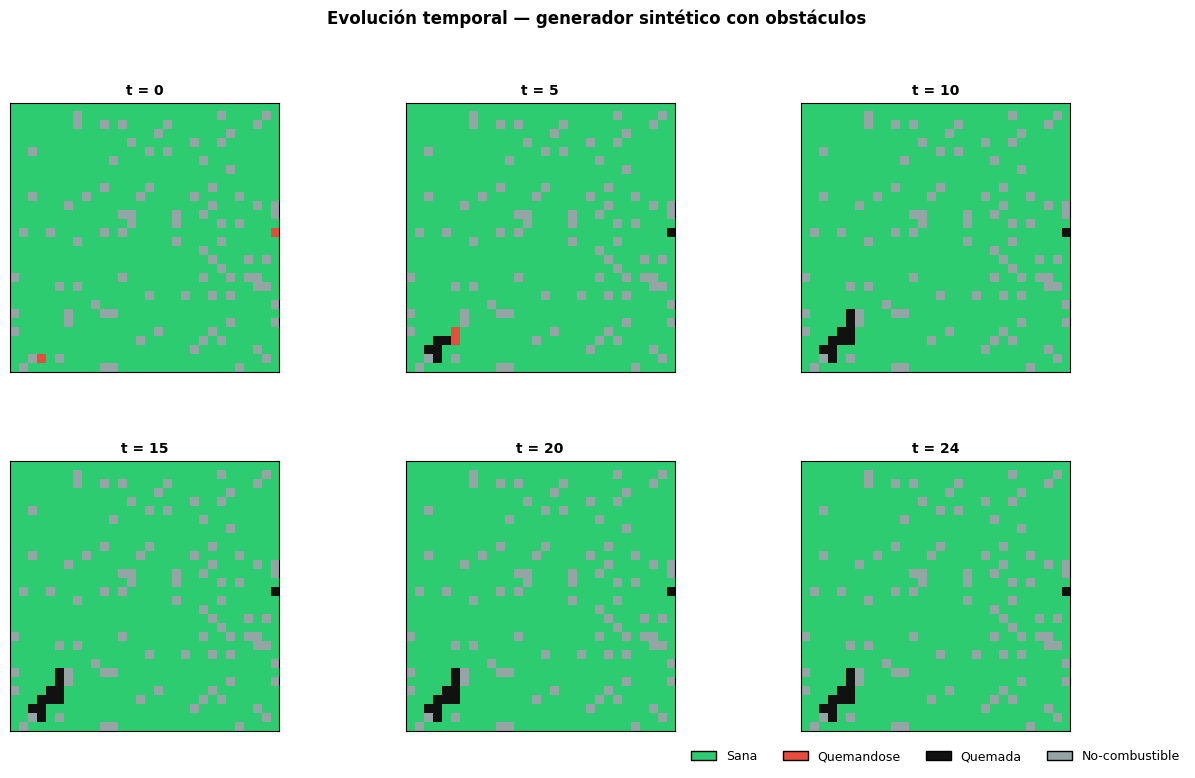

In [5]:
secuencia = generar_grid_dummy(
    n_pasos=25, tamano=30, n_puntos_ignicion=2,
    fraccion_no_combustible=0.10, duracion_quema=2, semilla=42
)

pasos = [0, 5, 10, 15, 20, 24]
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for idx, p in enumerate(pasos):
    ax = axes.flatten()[idx]
    dibujar_grid(secuencia[p], ax=ax, titulo=f"t = {p}", mostrar_leyenda=(idx == 5))
fig.suptitle("Evolución temporal — generador sintético con obstáculos", fontsize=12, weight="bold", y=1.0)
fig.tight_layout()
plt.show()

## Animación interactiva

Se genera una animación de 30 pasos sobre el modelo del Frente 2 con `animar_grid`. El reproductor integrado permite inspeccionar cada paso individualmente.

In [ ]:
sim = Grid(tamano=35, prob_ignicion_base=0.35, pasos_para_quemarse=2, semilla=123)
sim.encender_celda(17, 17)

secuencia_estados = [sim.estado.copy()]
for _ in range(30):
    sim.paso_tiempo()
    secuencia_estados.append(sim.estado.copy())

anim = animar_grid(
    secuencia_estados,
    intervalo=200,
    titulo_fn=lambda i: f"Frente 2 — Paso {i}"
)

plt.close(anim._fig)
HTML(anim.to_jshtml())

## Conclusiones

1. `dibujar_grid` y `animar_grid` representan fielmente los 4 estados categóricos sin artefactos de interpolación.
2. Las barreras no combustibles permanecen inertes durante toda la simulación, confirmando la compatibilidad de la capa de visualización con la introducción de máscaras geoespaciales en etapas posteriores (coberturas ESA WorldCover, hidrografía).
3. La capa de visualización queda desacoplada del motor de simulación y lista para consumir salidas calibradas con viento, pendiente SRTM y factores de vegetación.